# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize

In [2]:
from halo_and_cluster_MF import *
from functions_computations import *

# Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

Les valeurs suivantes et définitions de fonction de masse des amas (CMF) sont tirées de Friver et al. 2022.

# Implémentation

In [3]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
'''params_GSR_max = [14.13+0.43,-3.96+0.55,-1.68+0.21,0.63+0.25] # Borne max erreurs à 1 sigma
params_GSR_min = [14.13-0.40,-3.96-0.82,-1.68-0.24,0.63-0.11] # Borne min erreurs à 1 sigma'''

bounds_params_GSR = [(14.13-0.40,14.13+0.43),(-3.96-0.82,-3.96+0.55),(-1.68-0.24,-1.68+0.21),(0.63-0.11,0.63+0.25)]

# Params SR (SDSS5 + REFLEX II)
params_SR = [14.44,-4.52,-1.85,0.79] # valeurs moyennes 
'''params_SR_max = [14.44+0.25,-4.52+0.66,-1.85+0.21,0.79+0.23] # Borne max erreurs à 1 sigma
params_SR_min = [14.44-0.38,-4.52-0.58,-1.85-0.18,0.79-0.18] # Borne min erreurs à 1 sigma'''

bounds_params_SR = [(14.44-0.38,14.44+0.25),(-4.52-0.58,-4.52+0.66),(-1.85-0.18,-1.85+0.21),(0.79-0.18,0.79+0.23)]

# Params GR (GAMA5 + REFLEX II)
params_GR = [13.72,-3.44,-1.29,0.55] # valeurs moyennes
'''params_GR_max = [13.72+0.64,-3.44+0.26,-1.29+0.32,0.55+0.26] # Borne max erreurs à 1 sigma
params_GR_min = [13.72-0.43,-3.44-0.93,-1.29-0.41,0.55-0.08] # Borne min erreurs à 1 sigma'''

bounds_params_GR = [(13.72-0.43,13.72+0.64),(-3.44-0.93,-3.44+0.26),(-1.29-0.41,-1.29+0.32),(0.55-0.08,0.55+0.26)]

# Params GS (GAMA5 + SDSS5)
params_GS = [14.35,-4.38,-1.96,0.60] # valeurs moyennes
'''params_GS_max = [14.35+0.36,-4.38+0.93,-1.96+0.37,0.60+0.15] # Borne max erreurs à 1 sigma
params_GS_min = [14.35-0.60,-4.38-0.73,-1.96-0.18,0.60-0.10] # Borne min erreurs à 1 sigma'''

bounds_params_GS = [(14.35-0.60,14.35+0.36),(-4.38-0.73,-4.38+0.93),(-1.96-0.18,-1.96+0.37),(0.60-0.10,0.60+0.15)]

In [4]:
#On paramètres les CMF (Cluster Mass Function)

#GSR
CMF_GSR_func = CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])
'''CMF_GSR_max_func = CMF_MRP(params_GSR_max[0],params_GSR_max[1],params_GSR_max[2],params_GSR_max[3])
CMF_GSR_min_func = CMF_MRP(params_GSR_min[0],params_GSR_min[1],params_GSR_min[2],params_GSR_min[3])'''

#SR
CMF_SR_func = CMF_MRP(params_SR[0],params_SR[1],params_SR[2],params_SR[3])
'''CMF_SR_max_func = CMF_MRP(params_SR_max[0],params_SR_max[1],params_SR_max[2],params_SR_max[3])
CMF_SR_min_func = CMF_MRP(params_SR_min[0],params_SR_min[1],params_SR_min[2],params_SR_min[3])'''

#GR
CMF_GR_func = CMF_MRP(params_GR[0],params_GR[1],params_GR[2],params_GR[3])
'''CMF_GR_max_func = CMF_MRP(params_GR_max[0],params_GR_max[1],params_GR_max[2],params_GR_max[3])
CMF_GR_min_func = CMF_MRP(params_GR_min[0],params_GR_min[1],params_GR_min[2],params_GR_min[3])'''

#GS
CMF_GS_func = CMF_MRP(params_GS[0],params_GS[1],params_GS[2],params_GS[3])
'''CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])
CMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'''

'CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])\nCMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'

In [5]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
log10_M_Msun = log10_M_Msun.tolist()

print(log10_M_Msun)
type(log10_M_Msun)

[12.7, 12.702802802802802, 12.705605605605605, 12.708408408408408, 12.71121121121121, 12.714014014014014, 12.716816816816817, 12.71961961961962, 12.722422422422422, 12.725225225225225, 12.728028028028028, 12.730830830830831, 12.733633633633634, 12.736436436436435, 12.739239239239238, 12.74204204204204, 12.744844844844843, 12.747647647647646, 12.75045045045045, 12.753253253253252, 12.756056056056055, 12.758858858858858, 12.76166166166166, 12.764464464464464, 12.767267267267266, 12.77007007007007, 12.772872872872872, 12.775675675675675, 12.778478478478478, 12.78128128128128, 12.784084084084084, 12.786886886886887, 12.78968968968969, 12.792492492492492, 12.795295295295295, 12.798098098098098, 12.800900900900901, 12.803703703703704, 12.806506506506507, 12.809309309309308, 12.81211211211211, 12.814914914914914, 12.817717717717716, 12.82052052052052, 12.823323323323322, 12.826126126126125, 12.828928928928928, 12.83173173173173, 12.834534534534534, 12.837337337337337, 12.84014014014014, 12.84

list

In [6]:
# Propagation des erreurs sur les CMF à l'aide d'une méthode d'optimisation (on pourrait aussi essayer de récupérer les covatiances des paramètres (regarder le arxiv de Driver et al. 2022 ?) et aplliquer la formule de propagation des erreurs)

CMF_test = CMF_MRP_2(13.0) ; CMF_test_opposite = CMF_MRP_2_opposite(13.0)

'''result_CMF_test_min = minimize(fun = CMF_test, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP')
result_CMF_test_max = minimize(fun = CMF_test_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP') ; result_CMF_test_max = np.abs(result_CMF_test_max.fun) '''

Borne_min_CMF_GSR = [] ; Borne_max_CMF_GSR = []
Borne_min_CMF_SR = [] ; Borne_max_CMF_SR = []
Borne_min_CMF_GR = [] ; Borne_max_CMF_GR = []
Borne_min_CMF_GS = [] ; Borne_max_CMF_GS = []

for x in log10_M_Msun:
    CMF_current = CMF_MRP_2(x) ; CMF_current_opposite = CMF_MRP_2_opposite(x)

    #GSR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun) # On retrouve bien le max car la CMF est une fonction positive
    Borne_min_CMF_GSR.append(result_CMF_test_min) ; Borne_max_CMF_GSR.append(result_CMF_test_max)

    #SR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_SR.append(result_CMF_test_min) ; Borne_max_CMF_SR.append(result_CMF_test_max)

    #GR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GR.append(result_CMF_test_min) ; Borne_max_CMF_GR.append(result_CMF_test_max)

    #GS
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GS.append(result_CMF_test_min) ; Borne_max_CMF_GS.append(result_CMF_test_max)

    

In [7]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
'''CMF_GSR_max = CMF_GSR_max_func(log10_M_Msun)
CMF_GSR_min = CMF_GSR_min_func(log10_M_Msun)'''

CMF_SR = CMF_SR_func(log10_M_Msun)
'''CMF_SR_max = CMF_SR_max_func(log10_M_Msun)
CMF_SR_min = CMF_SR_min_func(log10_M_Msun)'''

CMF_GR = CMF_GR_func(log10_M_Msun)
'''CMF_GR_max = CMF_GR_max_func(log10_M_Msun)
CMF_GR_min = CMF_GR_min_func(log10_M_Msun)'''

CMF_GS = CMF_GS_func(log10_M_Msun)
'''CMF_GS_max = CMF_GS_max_func(log10_M_Msun)
CMF_GS_min = CMF_GS_min_func(log10_M_Msun)'''

'CMF_GS_max = CMF_GS_max_func(log10_M_Msun)\nCMF_GS_min = CMF_GS_min_func(log10_M_Msun)'

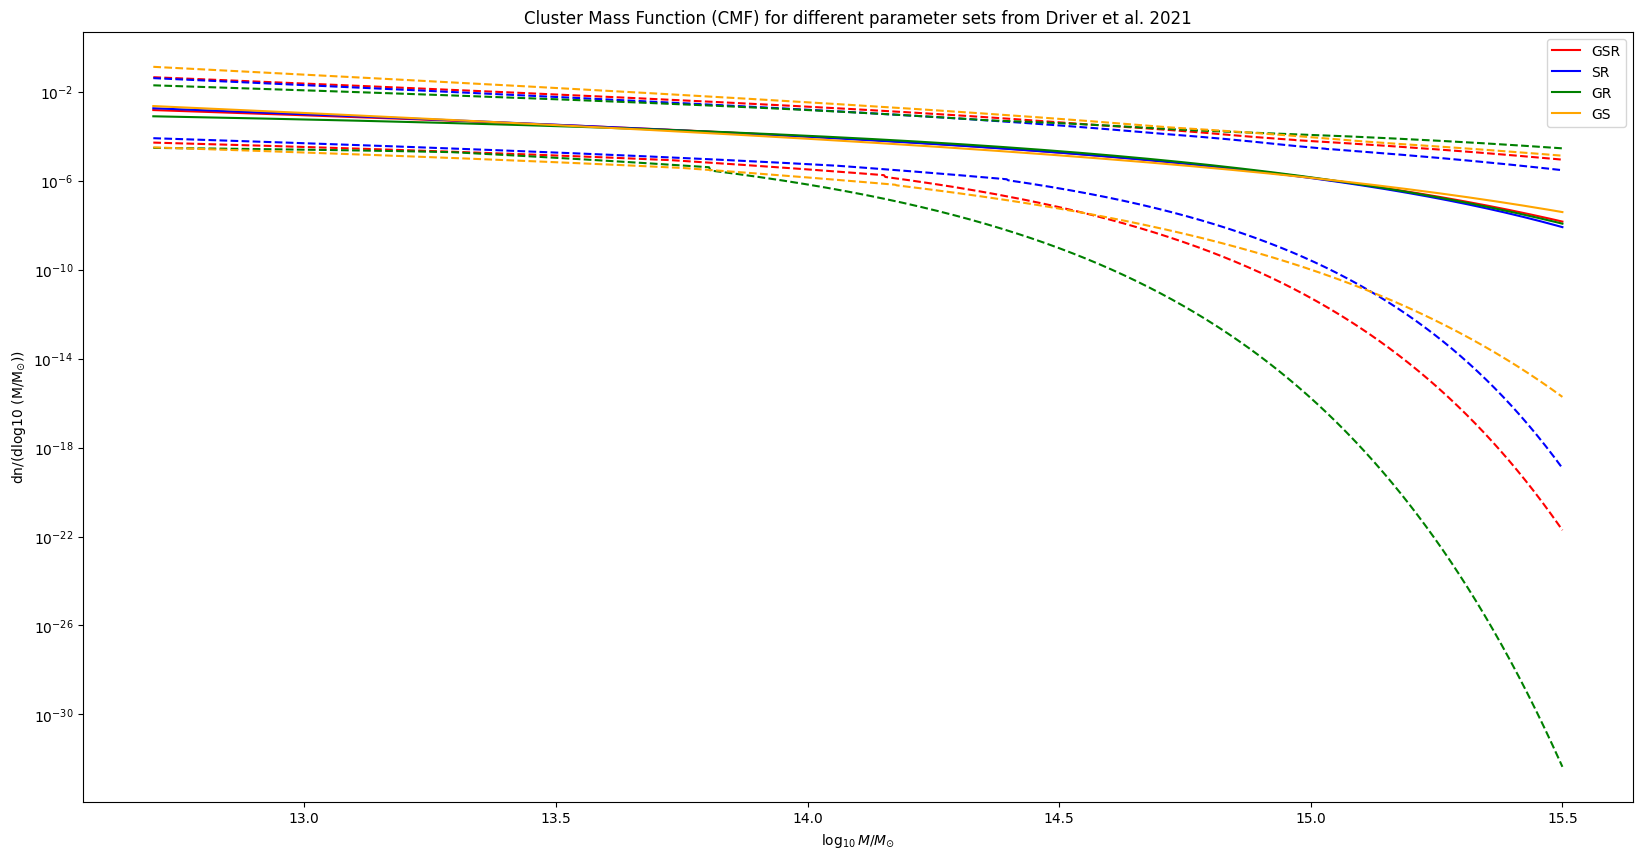

In [8]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()


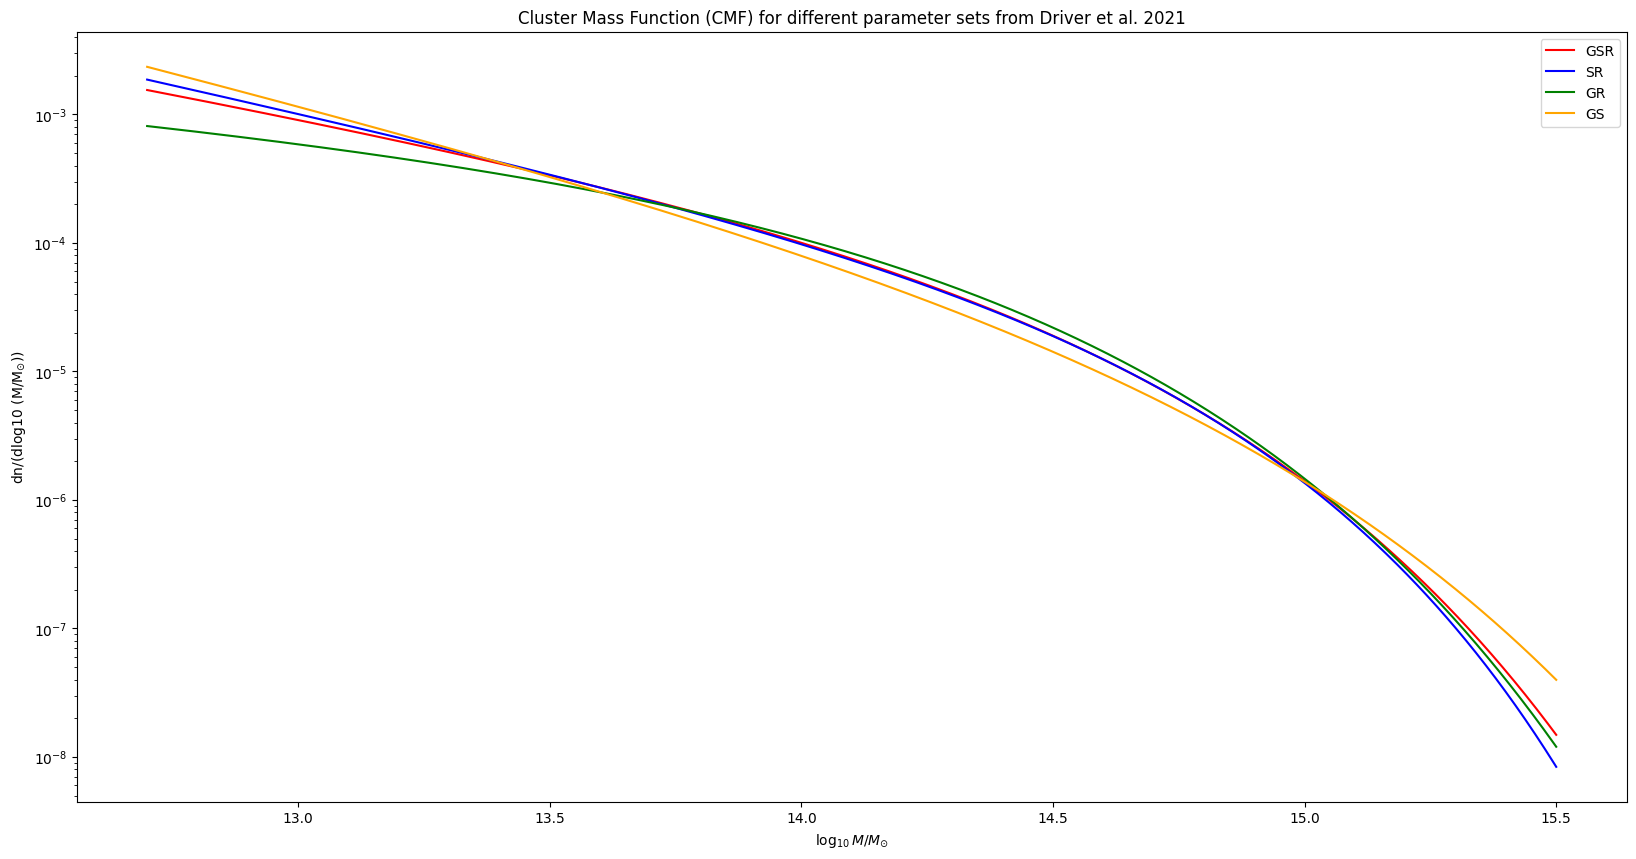

In [9]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')


plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')


plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()

# Calcul nombre d'amas

In [18]:
# Nombre théorique d'amas dans le volume couvert par DESI Legacy Imaging Surveys (Wen et Han 2024)
angular_area_deg2 = 24000 # Surface couverte par DESI Legacy Imaging Surveys en degrés carrés
bornes_z = [0,0.65] # Bornes de redshift pour lesquelles on calcule le nombre d'amas (DESI Legacy va jusqu'à z = 1.5)

bornes_log10_M_Msun = [12.7,15.5] # Bornes de masses pour lesquelles la fonction MRP est valable 

# GSR

mean_density = CMF_to_mean_density(CMF_GSR_func,bornes_log10_M_Msun)
volume = Volume_survey(angular_area_deg2,bornes_z)
N_GSR = mean_density * volume # Ce serait bien aussi de prendre en compte les erreurs pour avaoir une fourchette de valeurs

print('N_GSR = ',round(N_GSR/1e6,3),' millions d\'amas')

N_GSR =  6.049  millions d'amas
